In [6]:
import os

# Check files in C:\Users\hp\Downloads
print("--- FILES IN DOWNLOADS ---")
try:
    downloads_files = [f for f in os.listdir(r'C:\Users\hp\Downloads') if f.endswith(('.csv', '.zip'))]
    print(downloads_files)
except Exception as e:
    print(e)

# Check CSV files in C:\Users\hp
print("\n--- CSV FILES IN USER FOLDER ---")
user_files = [f for f in os.listdir(r'C:\Users\hp') if f.endswith(('.csv', '.zip'))]
print(user_files)


--- FILES IN DOWNLOADS ---
['About the company 3 Our Mission and Vision 4 Our Goals 5 Our Milestone 6 Our Offered Services 7 Contact us 8.zip', 'archive (1).zip', 'archive.zip', 'b_b2au8L9qFUJ-1772457753157.zip', 'Chapter-4-Handout.zip', 'Chapter-5-Handout.zip', 'Chapter-6 Handout.zip', 'code.zip', 'CSS_Practice.zip', 'DaVinci_Resolve_19.1.4_Windows.zip', 'demo.zip', 'Freshman_final_exams (1).zip', 'Freshman_final_exams.zip', 'ilovepdf_jpg-to-pdf (1).zip', 'ilovepdf_jpg-to-pdf.zip', 'ilovepdf_split-range.zip', 'limbiks_New Hist. 1012-pages-2.pdf.csv', 'OOP-first-semester-group-project-Pair-1.zip', 'Pair 1 + 2 integrated.zip', 'smallpdf-convert-20250512-150318.zip', 'source-code.zip', 'sqlite-src-3530300.zip', 'students  (2).csv', 'TSM-main (1).zip', 'TSM-main.zip']

--- CSV FILES IN USER FOLDER ---
[]


In [7]:
import zipfile

# Unzip archive.zip into your user folder C:\Users\hp
with zipfile.ZipFile(r'C:\Users\hp\Downloads\archive.zip', 'r') as zip_ref:
    zip_ref.extractall(r'C:\Users\hp')

print("Extracted successfully!")


Extracted successfully!


In [8]:
import os
print([f for f in os.listdir(r'C:\Users\hp') if f.endswith('.csv')])


['Sample - Superstore.csv']


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace 'train.csv' with whatever filename was printed in Step 2!
df = pd.read_csv('train.csv', encoding='latin1')

# Display the top 5 rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load using the exact extracted filename found in Cell [8]
df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

# Display the top 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
# Convert Order Date to datetime format and sort chronologically
df['Order Date'] = pd.to_datetime(df['Order Date'])
df = df.sort_values('Order Date')

# Aggregate sales by day
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()

# Ensure missing days are filled with 0 sales
daily_sales = daily_sales.set_index('Order Date').resample('D').sum().fillna(0).reset_index()

daily_sales.head()

,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060
2,2014-01-05,19.536
3,2014-01-06,4407.100
4,2014-01-07,87.158


In [12]:
# Calendar Features
daily_sales['Year'] = daily_sales['Order Date'].dt.year
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Day'] = daily_sales['Order Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Order Date'].dt.dayofweek
daily_sales['Is_Weekend'] = daily_sales['DayOfWeek'].isin([5, 6]).astype(int)

# Lag Features (Past performance)
daily_sales['Lag_1'] = daily_sales['Sales'].shift(1)    # Sales yesterday
daily_sales['Lag_7'] = daily_sales['Sales'].shift(7)    # Sales 7 days ago
daily_sales['Lag_30'] = daily_sales['Sales'].shift(30)  # Sales 30 days ago

# 7-Day Rolling Moving Average
daily_sales['Rolling_7_Mean'] = daily_sales['Sales'].shift(1).rolling(window=7).mean()

# Drop rows with NaN values created by shift/lag
daily_sales = daily_sales.dropna().reset_index(drop=True)

daily_sales.head()

,Order Date,Sales,Year,Month,Day,DayOfWeek,Is_Weekend,Lag_1,Lag_7,Lag_30,Rolling_7_Mean
0,2014-02-02,211.646,2014,2,2,6,1,468.900,1097.250,16.448,361.130571
1,2014-02-03,97.112,2014,2,3,0,0,211.646,426.670,288.060,234.615714
2,2014-02-04,134.384,2014,2,4,1,0,97.112,3.928,19.536,187.536000
3,2014-02-05,0.000,2014,2,5,2,0,134.384,0.000,4407.100,206.172571
4,2014-02-06,330.512,2014,2,6,3,0,0.000,240.500,87.158,206.172571


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Define input features and target
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Is_Weekend', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_7_Mean']
X = daily_sales[features]
y = daily_sales['Sales']

# Split 80% train, 20% test chronologically
split_idx = int(len(daily_sales) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test = daily_sales['Order Date'].iloc[split_idx:]

# Train Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict on test set
predictions = model.predict(X_test)

# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, predictions)
print(f"Model Training Complete!")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")

Model Training Complete!
Mean Absolute Error (MAE): $1650.28


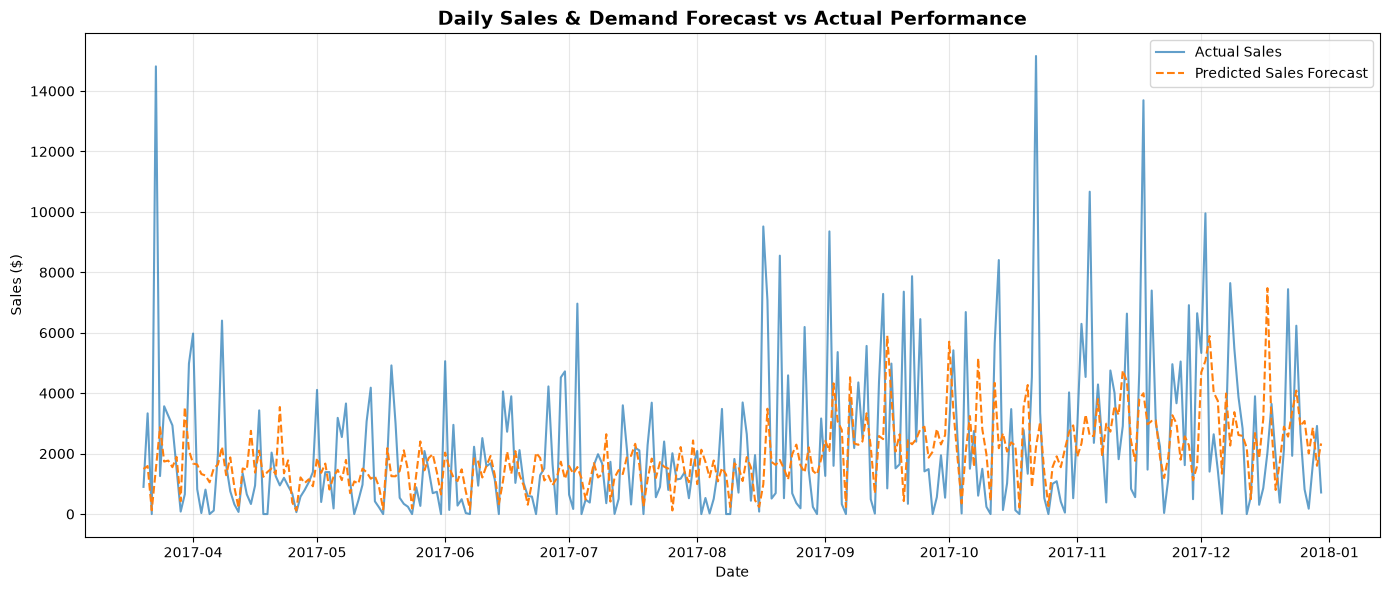

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test.values, label='Actual Sales', color='#1f77b4', alpha=0.7)
plt.plot(dates_test, predictions, label='Predicted Sales Forecast', color='#ff7f0e', linestyle='--')
plt.title('Daily Sales & Demand Forecast vs Actual Performance', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sales_forecast_plot.png', dpi=300, bbox_inches='tight')
plt.show()
